In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt 

In [5]:
import tensorflow as tf

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [7]:
from sklearn.preprocessing import normalize  

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

In [9]:
from tensorflow import keras

In [10]:
from tensorflow.keras import layers 

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
import xgboost as xgb

In [13]:
from sklearn.model_selection import KFold

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [15]:
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
from keras.optimizers import Adam

In [18]:
from keras.layers import LeakyReLU

In [19]:
dane = pd.read_csv("diabetes.csv")

In [20]:
dane.isna().sum()

pregnant      0
glucose       5
pressure     35
triceps     227
insulin     374
mass         11
age           0
diabetes      0
dtype: int64

In [21]:
columns_with_na = ["glucose", "pressure", "triceps", "insulin", "mass"]
for col in columns_with_na:
    dane[col].fillna(dane[col].median(), inplace=True)


In [22]:
dane.isna().sum()

pregnant    0
glucose     0
pressure    0
triceps     0
insulin     0
mass        0
age         0
diabetes    0
dtype: int64

In [23]:
dane['diabetes'] = dane['diabetes'].replace({'neg': 0, 'pos': 1})

In [24]:
X = dane.drop(columns=['diabetes'])  
y = dane['diabetes']                



In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)


In [26]:
np.random.seed(12)
tf.random.set_seed(12)

In [27]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train) 


In [28]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)


parametry = {
    'objective': 'multi:softmax', 
    'num_class': 2, 
    'max_depth': 3,
    'eta': 0.1,                   
    'seed': 42
}


model = xgb.train(parametry, dtrain, num_boost_round=200)


y_pred = model.predict(dtest)


print("Predykcje:", y_pred)

true = y_test.values
true



Predykcje: [1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1.
 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0.
 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 1. 0.]


array([0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0],
      dtype=int64)

In [29]:
accuracy_score(y_pred,true)

0.7597402597402597

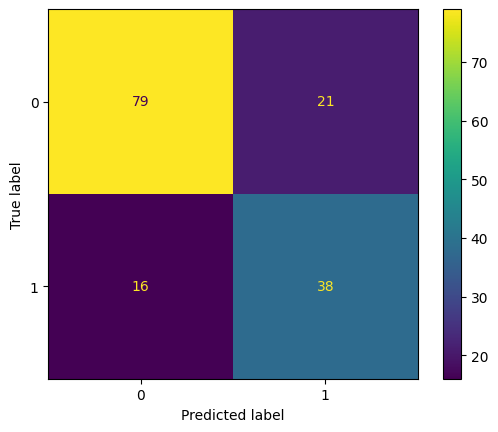

In [30]:
cm = confusion_matrix(true,y_pred)
ConfusionMatrixDisplay(cm).plot()

In [50]:
model = keras.Sequential()
model.add(keras.layers.Dense(64,activation='relu',input_dim=7))
model.add(LeakyReLU(alpha=0.3))
model.add(keras.layers.Dense(32,activation='relu'))
model.add(LeakyReLU(alpha=0.3))
model.add(keras.layers.Dense(16,activation='relu'))
model.add(LeakyReLU(alpha=0.4))
keras.layers.Dropout(0.3)
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.summary()

model.compile(Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])


c:\Users\mich4\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\mich4\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


AttributeError: module 'keras._tf_keras.keras' has no attribute 'add'

In [32]:
ES = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 50,
    
)

In [33]:
def reset_weights(model):
    for layer in model.layers:
        if hasattr(layer, 'kernel_initializer') and layer.kernel is not None:
            layer.kernel.assign(layer.kernel_initializer(tf.shape(layer.kernel)))
        if hasattr(layer, 'bias_initializer') and layer.bias is not None:
            layer.bias.assign(layer.bias_initializer(tf.shape(layer.bias)))

In [34]:
reset_weights(model)

In [35]:
history = model.fit(X_train, y_train, epochs=1000, batch_size=32,shuffle = True, validation_data=[X_test,y_test],callbacks=ES,verbose=1)


Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - AUC: 0.5548 - Precision: 0.5433 - Recall: 0.6337 - accuracy: 0.5360 - loss: 2.2366 - val_AUC: 0.5705 - val_Precision: 0.3810 - val_Recall: 0.8889 - val_accuracy: 0.4545 - val_loss: 2.0647
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.6329 - Precision: 0.5954 - Recall: 0.6891 - accuracy: 0.6014 - loss: 0.8594 - val_AUC: 0.5960 - val_Precision: 0.3913 - val_Recall: 0.8333 - val_accuracy: 0.4870 - val_loss: 1.1581
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.6773 - Precision: 0.6070 - Recall: 0.7512 - accuracy: 0.6233 - loss: 0.6993 - val_AUC: 0.6717 - val_Precision: 0.4400 - val_Recall: 0.8148 - val_accuracy: 0.5714 - val_loss: 0.8749
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7239 - Precision: 0.6598 - Recall: 0.7293 - accuracy: 0.6675 - loss: 0.6493 - val_AUC: 0.7143 - val_Precision: 0.4945 - val_Recall: 0.8333 - val_accuracy: 0.6429 - val_loss: 0.8243
Epoch 5/1000
25/25 ━━━━━━━━━━━━

In [36]:
predykcja_fnn = model.predict(X_test)
predykcja_fnn

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[9.43669498e-01],
       [2.69048089e-10],
       [5.25924921e-01],
       [7.04166770e-01],
       [5.73792681e-02],
       [3.96369845e-01],
       [3.37415546e-01],
       [9.78739619e-01],
       [2.56970197e-01],
       [9.41497862e-01],
       [3.77684712e-01],
       [4.31865364e-01],
       [3.23224783e-01],
       [5.18005848e-01],
       [5.87556481e-01],
       [7.42544413e-01],
       [7.27100849e-01],
       [3.40467781e-01],
       [9.79129970e-01],
       [4.54578102e-01],
       [5.52535176e-01],
       [1.24833956e-02],
       [7.12489367e-01],
       [8.68459165e-01],
       [7.79549837e-01],
       [1.41228169e-01],
       [9.60155070e-01],
       [2.99451798e-01],
       [8.20203662e-01],
       [1.80738509e-01],
       [1.26224652e-01],
       [2.45025411e-01],
       [7.34109998e-01],
       [9.55786645e-01],
       [6.90115571e-01],
       [2.05119595e-01],
       [5.22803843e-01],
       [2.83238977e-01],
       [5.27974606e-01],
       [2.79169887e-01],


In [37]:
predykcje_class = [1 if x[0] >= 0.6 else 0 for x in predykcja_fnn]

predykcje_class

[1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0]

In [38]:
predykcja_fnn.argmax(axis = 1 )

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [39]:
true_class = y_test

In [40]:
accuracy_score(true_class,predykcje_class)

0.7402597402597403

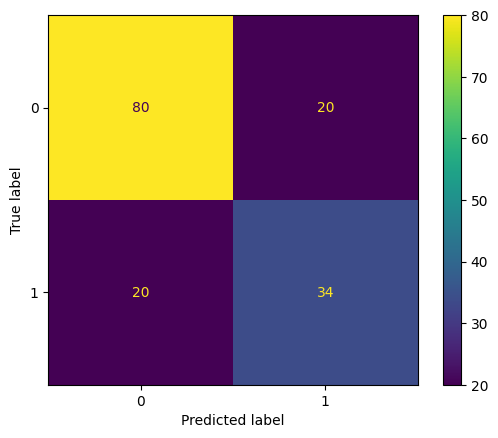

In [41]:
cm = confusion_matrix(true_class, predykcje_class)
ConfusionMatrixDisplay(cm).plot()

<Axes: >

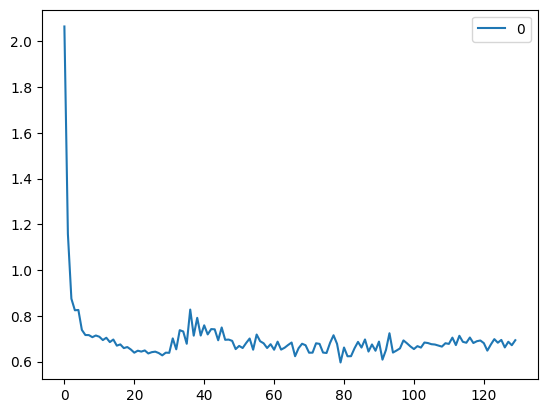

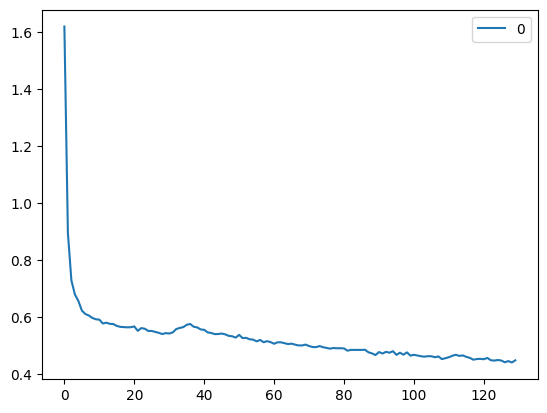

In [42]:
pd.DataFrame(history.history['val_loss']).plot()
pd.DataFrame(history.history['loss']).plot()

<Axes: >

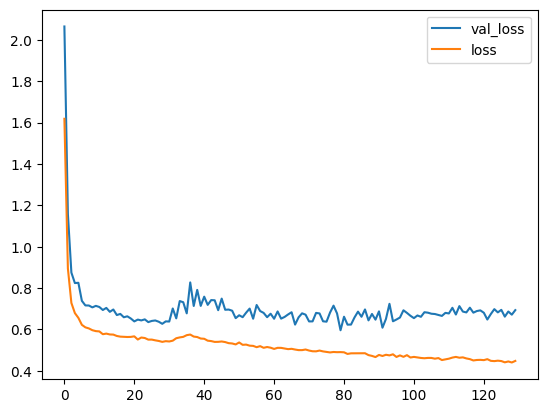

In [43]:
pd.DataFrame({'val_loss':history.history['val_loss'],'loss':history.history['loss']}).plot()

<Axes: >

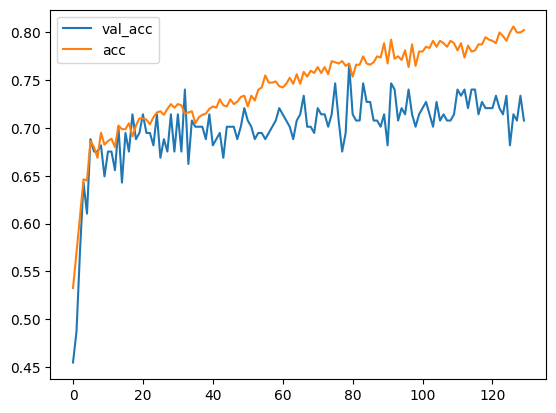

In [44]:
pd.DataFrame({'val_acc':history.history['val_accuracy'],'acc':history.history['accuracy']}).plot()

In [45]:
kf = KFold(n_splits=4)
solo_accs = []
losses = []
val_losses = []
accs = []
val_accs = []
i=-1

In [46]:
reset_weights(model)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


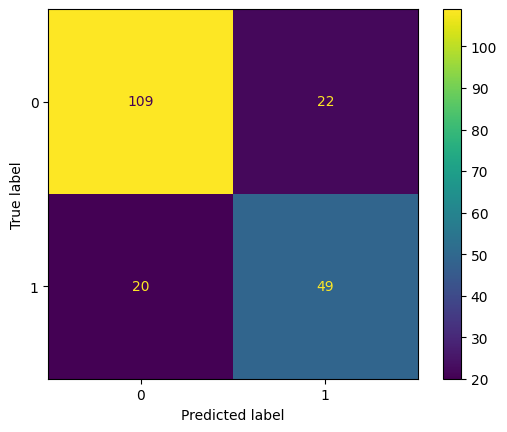

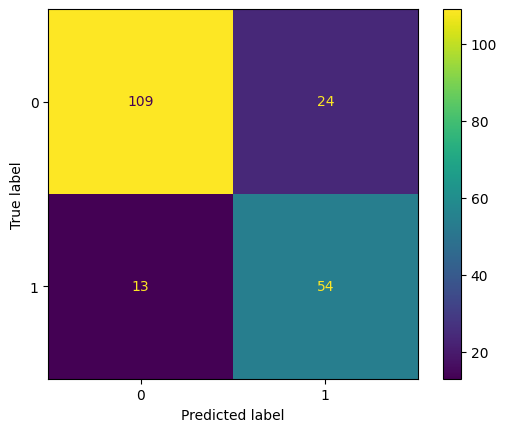

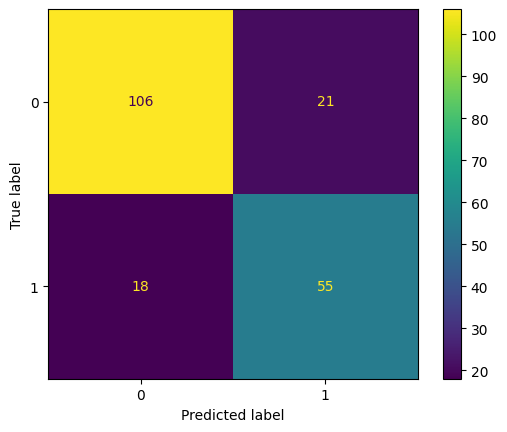

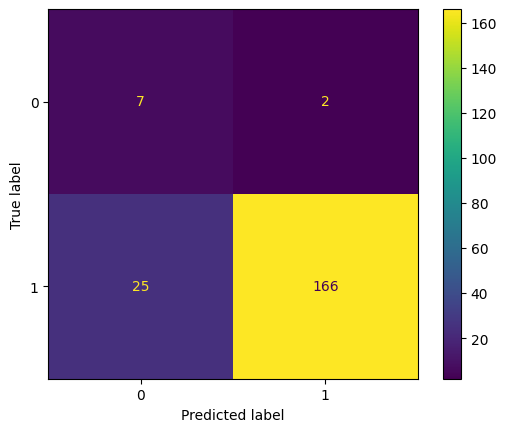

In [47]:
all_metrics = []
for train_id, val_id in kf.split(X_train):
    # Podział danych na treningowe i walidacyjne
    x_train = X_train.iloc[train_id]  
    x_val = X_train.iloc[val_id]     
    y_train_fold = y_train.iloc[train_id]  
    y_val_fold = y_train.iloc[val_id]     

    # Resetowanie wag modelu przed każdą iteracją
    reset_weights(model)

    # Trenowanie modelu
    history_k = model.fit(X_train, y_train, epochs=1000, batch_size=32,shuffle = True, validation_data=[X_test,y_test],callbacks=ES,verbose=0)

    # Predykcja na zbiorze walidacyjnym
    predykcje_k = (model.predict(x_val) > 0.6).astype("int32")  
    true_k = y_val_fold  

    # Obliczanie dokładności
    acc = accuracy_score(true_k, predykcje_k)
    solo_accs.append(acc)

    # Zbieranie wyników
    losses.append(history_k.history['loss'])
    val_losses.append(history_k.history['val_loss'])
    accs.append(history_k.history['accuracy'])
    val_accs.append(history_k.history['val_accuracy'])

    # Wyświetlanie macierzy 
    cm = confusion_matrix(true_k, predykcje_k)
    ConfusionMatrixDisplay(cm).plot()
    
    acc = accuracy_score(true_k,predykcje_k)
    solo_accs.append(acc)
    
    losses.append(history_k.history['loss'])
    val_losses.append(history_k.history['val_loss'])
    accs.append(history_k.history['accuracy'])
    val_accs.append(history_k.history['val_accuracy'])
    
    '''
    Precision: Procent prawdziwie pozytywnych przypadków wśród tych, które model przewidział jako pozytywne.
    Recall: Procent prawdziwie pozytywnych przypadków wśród wszystkich rzeczywistych pozytywnych przypadków.
    F1-score: Średnia harmoniczna precision i recall, która uwzględnia zarówno fałszywie pozytywne, jak i fałszywie negatywne klasyfikacje.
    '''
    
    precision = precision_score(true_k, predykcje_k)
    recall = recall_score(true_k, predykcje_k)
    f1 = f1_score(true_k, predykcje_k)
    
    metrics = {
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

    all_metrics.append(metrics)

In [48]:
for idx, metrics in enumerate(all_metrics):
    print(f"Iteration {idx + 1}:")
    print(f"  Precision: {metrics['precision']:.2f}")
    print(f"  Recall: {metrics['recall']:.2f}")
    print(f"  F1-score: {metrics['f1_score']:.2f}")
    print("-" * 40)

Iteration 1:
  Precision: 0.69
  Recall: 0.71
  F1-score: 0.70
----------------------------------------
Iteration 2:
  Precision: 0.69
  Recall: 0.81
  F1-score: 0.74
----------------------------------------
Iteration 3:
  Precision: 0.72
  Recall: 0.75
  F1-score: 0.74
----------------------------------------
Iteration 4:
  Precision: 0.99
  Recall: 0.87
  F1-score: 0.92
----------------------------------------


In [49]:
glob_acc = np.mean(solo_accs)
glob_acc_std = np.std(solo_accs)
print(f"global acc: {glob_acc} std: {glob_acc_std}")

global acc: 0.81875 std: 0.02814582562299424
